https://www.kaggle.com/datasets/yacharki/yelp-reviews-for-sentianalysis-binary-np-csv

 Problem Statement Use a Pretrained Transformer for Text Classification — pip install transformers, then load the default pipeline: pipeline("sentiment-analysis") — this downloads a small, ready-made model automatically and needs no training or GPU. Take a random sample of 100–200 rows of text, get the label your dataset actually gives each row (see the Note below for the exact mapping to POSITIVE/NEGATIVE for your set), run the pipeline on the sampled text, and compute what fraction of its POSITIVE/NEGATIVE predictions match your label. Print 3–5 example rows (text, true label, predicted label). In 1–2 sentences, explain what "attention" lets this model consider that a Bag-of-Words word count cannot.

Install Transformers

In [23]:
!pip install -q transformers

Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import pipeline
from sklearn.metrics import accuracy_score

Load the dataset

In [3]:
df = pd.read_csv("test.csv")

df.head()

,class_index,review_text
0,2,"Contrary to other reviews, I have zero complai..."
1,1,Last summer I had an appointment to get new ti...
2,2,"Friendly staff, same starbucks fair you get an..."
3,1,The food is good. Unfortunately the service is...
4,2,Even when we didn't have a car Filene's Baseme...


Dataset shape and columns

In [24]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

Dataset Shape: (38000, 5)

Column Names:
Index(['class_index', 'review_text', 'review_length', 'word_count',
       'true_label'],
      dtype='object')


Dataset information

In [25]:
print("Dataset Information:")

df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38000 entries, 0 to 37999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   class_index    38000 non-null  int64 
 1   review_text    38000 non-null  object
 2   review_length  38000 non-null  int64 
 3   word_count     38000 non-null  int64 
 4   true_label     38000 non-null  object
dtypes: int64(3), object(2)
memory usage: 1.4+ MB


Data types

In [26]:
print("Data Types:")

print(df.dtypes)

Data Types:
class_index       int64
review_text      object
review_length     int64
word_count        int64
true_label       object
dtype: object


Statistical summary

In [27]:
print("Statistical Summary:")

display(df.describe(include="all"))

Statistical Summary:


,class_index,review_text,review_length,word_count,true_label
count,38000.000000,38000,38000.000000,38000.000000,38000
unique,NaN,38000,NaN,NaN,2
top,NaN,"Watered down milkshakes, the place smells like...",NaN,NaN,POSITIVE
freq,NaN,1,NaN,NaN,19000
mean,1.500000,NaN,723.237684,132.558632,NaN
std,0.500007,NaN,661.465021,121.216615,NaN
min,1.000000,NaN,4.000000,1.000000,NaN
25%,1.000000,NaN,280.000000,51.000000,NaN
50%,1.500000,NaN,527.000000,97.000000,NaN
75%,2.000000,NaN,943.000000,173.000000,NaN


Class distribution

In [28]:
print("Class Counts:")

print(
    df["class_index"]
    .value_counts()
    .sort_index()
)

print("\nClass Percentages:")

print(
    df["class_index"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

Class Counts:
class_index
1    19000
2    19000
Name: count, dtype: int64

Class Percentages:
class_index
1    50.0
2    50.0
Name: proportion, dtype: float64


## Initial Inspection Findings

The Yelp dataset contains approximately 38,000 reviews with two original
columns: class_index and review_text.

The class_index column represents the sentiment category, while review_text
contains the written customer review. The class distribution is checked to
determine whether positive and negative reviews are balanced before applying
the sentiment model.

Missing Values

In [29]:
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
class_index      0
review_text      0
review_length    0
word_count       0
true_label       0
dtype: int64


Handle missing text if necessary

In [30]:
df = df.dropna(
    subset=["class_index", "review_text"]
)

print("Missing Values After Cleaning:")

print(df.isnull().sum())

Missing Values After Cleaning:
class_index      0
review_text      0
review_length    0
word_count       0
true_label       0
dtype: int64


Check duplicates

In [31]:
duplicate_count = df.duplicated().sum()

print(
    "Number of duplicate rows:",
    duplicate_count
)

Number of duplicate rows: 0


Remove duplicates

In [32]:
df = df.drop_duplicates().copy()

print(
    "Duplicates after removal:",
    df.duplicated().sum()
)

Duplicates after removal: 0


Create review length

In [33]:
df["review_length"] = (
    df["review_text"]
    .astype(str)
    .str.len()
)

df[
    ["review_text", "review_length"]
].head()

,review_text,review_length
0,"Contrary to other reviews, I have zero complai...",681
1,Last summer I had an appointment to get new ti...,370
2,"Friendly staff, same starbucks fair you get an...",93
3,The food is good. Unfortunately the service is...,300
4,Even when we didn't have a car Filene's Baseme...,783


Create word count

In [34]:
df["word_count"] = (
    df["review_text"]
    .astype(str)
    .str.split()
    .str.len()
)

df[
    [
        "review_text",
        "review_length",
        "word_count"
    ]
].head()

,review_text,review_length,word_count
0,"Contrary to other reviews, I have zero complai...",681,126
1,Last summer I had an appointment to get new ti...,370,71
2,"Friendly staff, same starbucks fair you get an...",93,15
3,The food is good. Unfortunately the service is...,300,53
4,Even when we didn't have a car Filene's Baseme...,783,138


Inspect engineered features

In [35]:
print("Engineered Feature Statistics:")

display(
    df[
        ["review_length", "word_count"]
    ].describe()
)

Engineered Feature Statistics:


,review_length,word_count
count,38000.000000,38000.000000
mean,723.237684,132.558632
std,661.465021,121.216615
min,4.000000,1.000000
25%,280.000000,51.000000
50%,527.000000,97.000000
75%,943.000000,173.000000
max,5093.000000,1007.000000


Word-count outliers

In [36]:
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

word_outliers = df[
    (df["word_count"] < lower_bound) |
    (df["word_count"] > upper_bound)
]

print("Word Count Q1:", Q1)
print("Word Count Q3:", Q3)
print("Word Count IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print(
    "Potential Word Count Outliers:",
    len(word_outliers)
)

Word Count Q1: 51.0
Word Count Q3: 173.0
Word Count IQR: 122.0
Lower Bound: -132.0
Upper Bound: 356.0
Potential Word Count Outliers: 2061


Review-length outliers

In [37]:
Q1_length = df["review_length"].quantile(0.25)
Q3_length = df["review_length"].quantile(0.75)

IQR_length = Q3_length - Q1_length

lower_length = Q1_length - 1.5 * IQR_length
upper_length = Q3_length + 1.5 * IQR_length

length_outliers = df[
    (df["review_length"] < lower_length) |
    (df["review_length"] > upper_length)
]

print("Review Length Q1:", Q1_length)
print("Review Length Q3:", Q3_length)
print("Review Length IQR:", IQR_length)

print(
    "Potential Review Length Outliers:",
    len(length_outliers)
)

Review Length Q1: 280.0
Review Length Q3: 943.0
Review Length IQR: 663.0
Potential Review Length Outliers: 2110


Sentiment Distribution

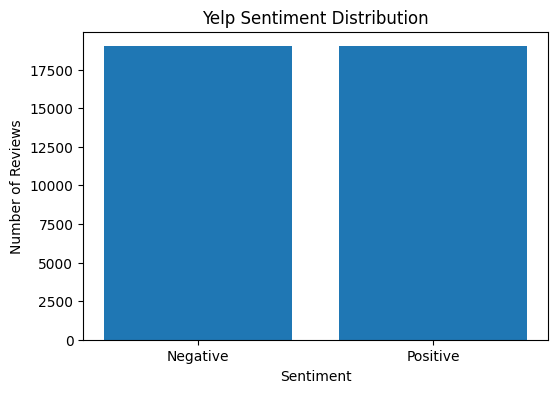

In [38]:
class_counts = (
    df["class_index"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["Negative", "Positive"],
    [
        class_counts.get(1, 0),
        class_counts.get(2, 0)
    ]
)

plt.title("Yelp Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

Word Count Distribution

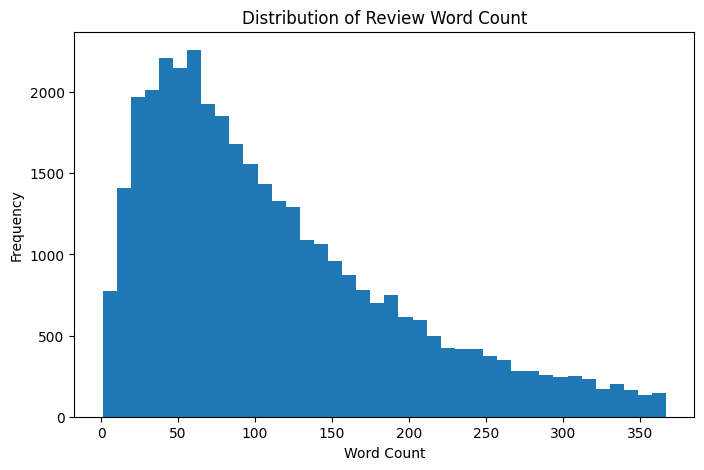

In [39]:
word_limit = df["word_count"].quantile(0.95)

plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[
        df["word_count"] <= word_limit,
        "word_count"
    ],
    bins=40
)

plt.title("Distribution of Review Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

Review Length Distribution

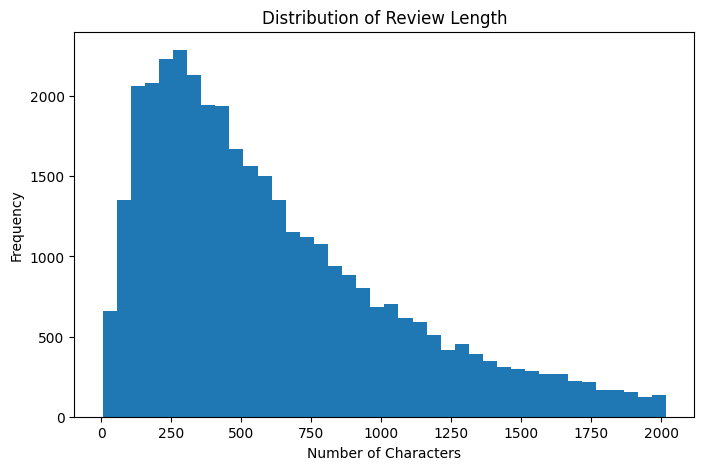

In [40]:
length_limit = df["review_length"].quantile(0.95)

plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[
        df["review_length"] <= length_limit,
        "review_length"
    ],
    bins=40
)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

Correlation Matrix

In [41]:
corr_data = df[
    [
        "class_index",
        "review_length",
        "word_count"
    ]
].corr()

print(corr_data)

               class_index  review_length  word_count
class_index       1.000000      -0.144748   -0.154733
review_length    -0.144748       1.000000    0.996917
word_count       -0.154733       0.996917    1.000000


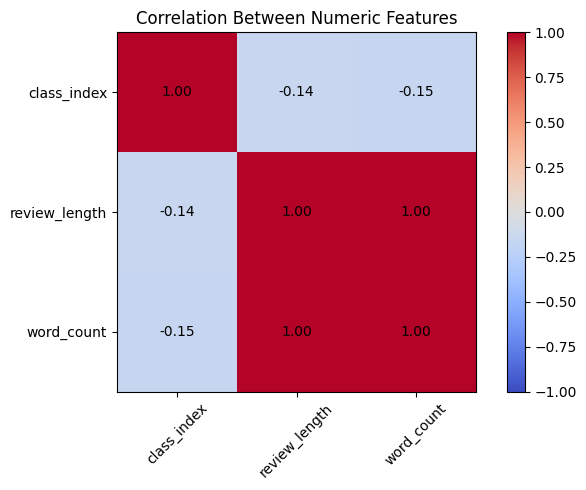

In [42]:
plt.figure(figsize=(7, 5))

plt.imshow(
    corr_data,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar()

plt.xticks(
    range(len(corr_data.columns)),
    corr_data.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_data.columns)),
    corr_data.columns
)

for i in range(len(corr_data.columns)):
    for j in range(len(corr_data.columns)):

        plt.text(
            j,
            i,
            f"{corr_data.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title(
    "Correlation Between Numeric Features"
)

plt.tight_layout()

plt.show()

Generate Statistics for Insights

In [43]:
print("===== DATASET SUMMARY =====")

print("\nTotal Reviews:")
print(len(df))


print("\nClass Counts:")
print(
    df["class_index"]
    .value_counts()
    .sort_index()
)


print("\nClass Percentages:")
print(
    df["class_index"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)


print("\nMissing Values:")
print(
    df[
        ["class_index", "review_text"]
    ].isnull().sum()
)


print("\nDuplicate Rows:")
print(df.duplicated().sum())


print("\nAverage Word Count:")
print(df["word_count"].mean())


print("\nMedian Word Count:")
print(df["word_count"].median())


print("\nAverage Word Count by Class:")
print(
    df.groupby("class_index")[
        "word_count"
    ].mean()
)


print("\nAverage Review Length by Class:")
print(
    df.groupby("class_index")[
        "review_length"
    ].mean()
)


print("\nCorrelation Matrix:")
print(corr_data)

===== DATASET SUMMARY =====

Total Reviews:
38000

Class Counts:
class_index
1    19000
2    19000
Name: count, dtype: int64

Class Percentages:
class_index
1    50.0
2    50.0
Name: proportion, dtype: float64

Missing Values:
class_index    0
review_text    0
dtype: int64

Duplicate Rows:
0

Average Word Count:
132.55863157894737

Median Word Count:
97.0

Average Word Count by Class:
class_index
1    151.314579
2    113.802684
Name: word_count, dtype: float64

Average Review Length by Class:
class_index
1    818.982263
2    627.493105
Name: review_length, dtype: float64

Correlation Matrix:
               class_index  review_length  word_count
class_index       1.000000      -0.144748   -0.154733
review_length    -0.144748       1.000000    0.996917
word_count       -0.154733       0.996917    1.000000


Prepare Correct Sentiment Labels

In [44]:
df["true_label"] = df["class_index"].map({
    1: "NEGATIVE",
    2: "POSITIVE"
})

df[
    [
        "class_index",
        "true_label",
        "review_text"
    ]
].head()

,class_index,true_label,review_text
0,2,POSITIVE,"Contrary to other reviews, I have zero complai..."
1,1,NEGATIVE,Last summer I had an appointment to get new ti...
2,2,POSITIVE,"Friendly staff, same starbucks fair you get an..."
3,1,NEGATIVE,The food is good. Unfortunately the service is...
4,2,POSITIVE,Even when we didn't have a car Filene's Baseme...


Verify labels

In [45]:
print(
    df["true_label"]
    .value_counts()
)

true_label
POSITIVE    19000
NEGATIVE    19000
Name: count, dtype: int64


Random Sample of 200 Reviews

In [46]:
sample_df = df.sample(
    n=200,
    random_state=42
).copy()

print(
    "Number of sampled reviews:",
    len(sample_df)
)

sample_df.head()

Number of sampled reviews: 200


,class_index,review_text,review_length,word_count,true_label
28631,1,I expected the prices of the entrees to be a l...,811,147,NEGATIVE
9134,1,Review of Buffet:\n\nUGH! It was very very un...,227,38,NEGATIVE
26464,1,"If you value your life, don't go to Banner Bos...",1446,270,NEGATIVE
9477,2,"Before getting started, I'd like to point out ...",3266,585,POSITIVE
5954,1,Very disappointed in this salon. Set an appt 4...,244,49,NEGATIVE


Load Pretrained Transformer

In [47]:
sentiment_model = pipeline(
    "sentiment-analysis"
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Prepare Text

In [48]:
texts = (
    sample_df["review_text"]
    .astype(str)
    .tolist()
)

print(
    "Number of texts:",
    len(texts)
)

Number of texts: 200


Transformer Predictions

In [49]:
predictions = sentiment_model(
    texts,
    truncation=True,
    max_length=512
)

Inspect first predictions

In [50]:
print(
    predictions[:5]
)

[{'label': 'NEGATIVE', 'score': 0.9997571110725403}, {'label': 'NEGATIVE', 'score': 0.9982579350471497}, {'label': 'NEGATIVE', 'score': 0.9974949359893799}, {'label': 'NEGATIVE', 'score': 0.998444139957428}, {'label': 'NEGATIVE', 'score': 0.999739944934845}]


Save Predictions

In [51]:
sample_df["predicted_label"] = [
    result["label"]
    for result in predictions
]

sample_df["confidence"] = [
    result["score"]
    for result in predictions
]

Check results

In [52]:
display(
    sample_df[
        [
            "review_text",
            "true_label",
            "predicted_label",
            "confidence"
        ]
    ].head()
)

,review_text,true_label,predicted_label,confidence
28631,I expected the prices of the entrees to be a l...,NEGATIVE,NEGATIVE,0.999757
9134,Review of Buffet:\n\nUGH! It was very very un...,NEGATIVE,NEGATIVE,0.998258
26464,"If you value your life, don't go to Banner Bos...",NEGATIVE,NEGATIVE,0.997495
9477,"Before getting started, I'd like to point out ...",POSITIVE,NEGATIVE,0.998444
5954,Very disappointed in this salon. Set an appt 4...,NEGATIVE,NEGATIVE,0.999740


Calculate Accuracy

In [53]:
accuracy = accuracy_score(
    sample_df["true_label"],
    sample_df["predicted_label"]
)

print(
    "Accuracy:",
    accuracy
)

print(
    f"Accuracy Percentage: {accuracy * 100:.2f}%"
)

Accuracy: 0.905
Accuracy Percentage: 90.50%


Correct vs Incorrect Predictions

In [54]:
sample_df["correct"] = (
    sample_df["true_label"]
    ==
    sample_df["predicted_label"]
)

correct_predictions = (
    sample_df["correct"].sum()
)

incorrect_predictions = (
    len(sample_df)
    - correct_predictions
)

print("===== TRANSFORMER RESULTS =====")

print(
    "Sample Size:",
    len(sample_df)
)

print(
    "Correct Predictions:",
    correct_predictions
)

print(
    "Incorrect Predictions:",
    incorrect_predictions
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

print(
    f"Fraction Correct: "
    f"{correct_predictions}/{len(sample_df)}"
)

===== TRANSFORMER RESULTS =====
Sample Size: 200
Correct Predictions: 181
Incorrect Predictions: 19
Accuracy: 90.50%
Fraction Correct: 181/200


## Attention Explanation

Attention allows the Transformer to consider how different words in a sentence
relate to each other and which words are most important for understanding the
meaning. Bag-of-Words mainly counts words and cannot understand word order,
context, or relationships between words.